In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn import tree

from sklearn import metrics

from scipy import stats

# Load data

In [18]:
data = pd.read_csv('data/1.0-lbm-flowmeter_A.txt', sep="\t", header=None).dropna()

data.head()

#data = data.iloc[:, 0:15]

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,0.841499,1.009367,0.993816,8.469805,10.278727,10.037759,8.501365,8.581726,10.247763,10.058822,...,32.451173,34.568685,33.082683,36.722005,36.969403,36.075847,36.051432,35.174155,32.729490,1
1,0.842250,1.006584,0.996605,7.531891,9.139924,8.951618,7.612213,7.623325,9.106345,8.945142,...,32.428385,34.441732,33.081055,36.687825,36.933595,36.054688,35.979818,34.847005,32.731122,1
2,0.840723,1.011647,0.998152,6.641699,7.975464,7.857692,6.593117,6.681572,7.964596,7.814698,...,32.428385,34.275715,33.113605,36.661785,36.873370,36.002605,35.963542,34.689128,32.771810,1
3,0.841119,1.017807,0.996812,5.687524,6.824334,6.689885,5.615428,5.763315,6.801051,6.686639,...,32.485350,34.080403,33.170573,36.673177,36.811525,35.974935,35.955403,34.500328,32.849935,1
4,0.840358,1.016534,0.996221,5.660385,6.829560,6.675628,5.623977,5.736818,6.813453,6.672377,...,32.503255,34.122720,33.164062,36.673177,36.826173,35.996095,35.968425,34.474283,32.853190,1


c:\Users\luisa\Anaconda3\envs\labm\lib\site-packages\ipykernel_launcher.py:12: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  if sys.path[0] == '':


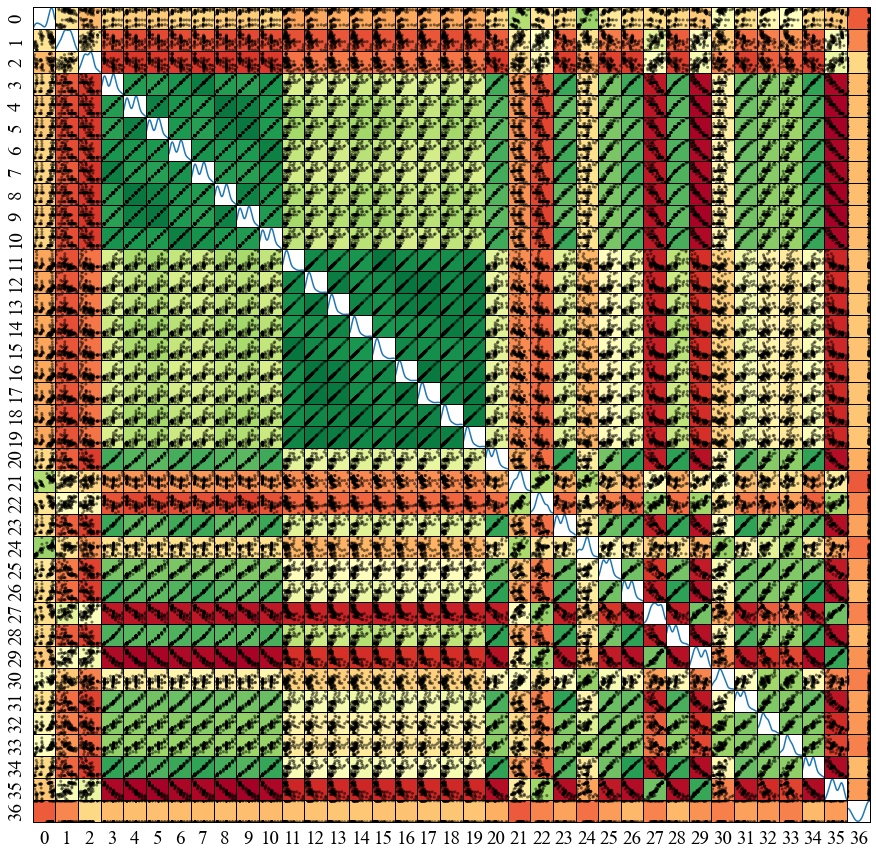

In [24]:
from scipy import stats
from matplotlib import cm
import matplotlib

def plot_matrix(data):

    n = len(data)*len(data.columns)

    fig = plt.figure(figsize = (15, 15))
    axs0 = fig.add_subplot(1, 2, 1)

    matrix = pd.plotting.scatter_matrix(data, color = 'k', diagonal = 'kde', ax = axs0)

    correlation = data.corr()
    #print(correlation)

    correlation_list = np.asarray(correlation).flatten().tolist()

    correlation_list.sort()

    cmap = cm.get_cmap('RdYlGn', len(correlation_list))    # PiYG

    colors = []
    for i in range(cmap.N):
        rgba = cmap(i)
        # rgb2hex accepts rgb or rgba
        colors.append(matplotlib.colors.rgb2hex(rgba))

    colors_dict = dict(zip(correlation_list, colors))

    for ax in fig.get_axes():

        x = ax.xaxis.get_label().get_text()
        y = ax.yaxis.get_label().get_text()

        #print(int(x), int(y))
        
        corr = correlation[int(x)][int(y)]
        #print(corr)
        if x != y:
            ax.set_facecolor(colors_dict[corr])

        # xmin, xmax = ax.get_xlim()
        # ymin, ymax = ax.get_ylim()


        ax.xaxis.set_tick_params(labelbottom=False)
        ax.yaxis.set_tick_params(labelleft=False)

        ax.set_xticks([])
        ax.set_yticks([])

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=19
    plt.rcParams['axes.linewidth'] = 1 
    plt.xticks(rotation = 45)
    plt.yticks(rotation = 45)
    #plt.legend(frameon = False)
    #plt.tight_layout()
    plt.savefig(f'figures/example-6-1-matrix.png', dpi = 300)
    plt.show()

    return None

plot_matrix(data)


# Preprocess data

In [ ]:
data = data.to_numpy()

x = data[:, :-1]
y = data[:, -1]

#We want classes to be 0 and 1
for i in range(len(y)):
    if y[i] == 1:
        y[i] = 0

    else:
        y[i] = 1

#Data preprocessing
scaler = StandardScaler()
x = scaler.fit_transform(x)

#Create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.5,
                                                    shuffle=True)

# Train a decision tree model

0.8409090909090909


[Text(0.4, 0.9, 'X[0] <= -0.113\nentropy = 0.968\nsamples = 43\nvalue = [17, 26]'),
 Text(0.2, 0.7, 'entropy = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.6, 0.7, 'X[0] <= 0.951\nentropy = 0.951\nsamples = 27\nvalue = [17, 10]'),
 Text(0.4, 0.5, 'X[27] <= 1.185\nentropy = 0.61\nsamples = 20\nvalue = [17, 3]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.6, 0.3, 'X[33] <= -0.431\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]'),
 Text(0.4, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.1, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 7\nvalue = [0, 7]')]

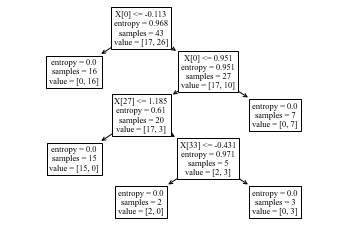

In [ ]:
#Create DT model
DT_classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)

#Train the model
DT_classifier.fit(X_train, y_train)

#Test the model
DT_predicted = DT_classifier.predict(X_test)

DT_accuracy = metrics.accuracy_score(y_test, DT_predicted)

print(DT_accuracy)



# Train a support vector machine model

In [ ]:
#Create SVC model
SVC_classifier = SVC(random_state = 42)

#Train the model
SVC_classifier.fit(X_train, y_train)

#Test the model
SVC_predicted = SVC_classifier.predict(X_test)

SVC_accuracy = metrics.accuracy_score(y_test, SVC_predicted)

print(SVC_accuracy)

0.7954545454545454


# Train an artificial neural network (MLP) model

In [ ]:
#Create MLP model
MLP_classifier = MLPClassifier(random_state = 42)

#Train the model
MLP_classifier.fit(X_train, y_train)

#Test the model
MLP_predicted = MLP_classifier.predict(X_test)

MLP_accuracy = metrics.accuracy_score(y_test, MLP_predicted)

print(MLP_accuracy)




0.9772727272727273


c:\Users\luisa\Anaconda3\envs\labm\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


36

layer_0: 36)
layer_1: 100)


# Compare results with default hyperparameters

In [ ]:
def plot_roc(clfs, test = 'default'):

    fig = plt.figure(figsize=(6, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for clf in clfs:
        metrics.RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axs0)

    for ax in ['top', 'bottom', 'left', 'right']:
            axs0.spines[ax].set_linewidth(1)

    axs0.xaxis.label.set_size('x-large')
    axs0.yaxis.label.set_size('x-large')

    axs0.tick_params(direction='out',
                            pad=10,
                            length=9,
                            width=1,
                            labelsize='x-large')

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 
    plt.legend(frameon = False)
    plt.tight_layout()
    plt.savefig(f'figures/example-6-1-{test}.png', dpi = 300)
    plt.show()

    return None

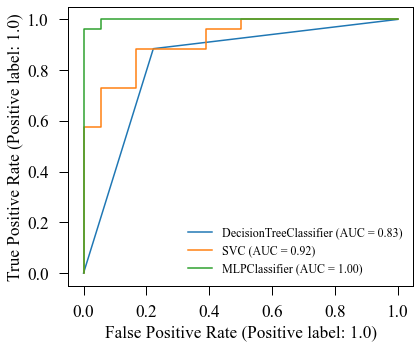

In [ ]:
clfs = [
        DT_classifier,
        SVC_classifier,
        MLP_classifier
    ]
    
plot_roc(clfs)

## Get model structures

In [ ]:
for i, layer in enumerate(MLP_classifier.coefs_):
    print(f'layer_{i}: {len(MLP_classifier.coefs_[i])})')

In [ ]:
tree.plot_tree(DT_classifier)

# Performance with improved hyperparameters

c:\Users\luisa\Anaconda3\envs\labm\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:696: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  ConvergenceWarning,


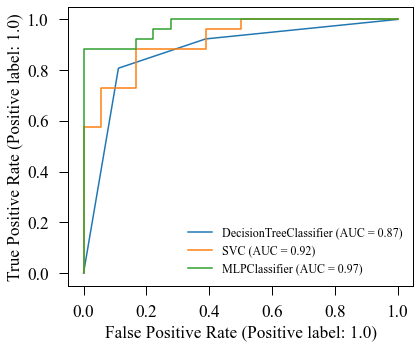

In [ ]:
DT_classifier_improved = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, random_state = 42)
SVC_classifier_improved = SVC(C = 0.1, random_state = 42)
MLP_classifier_improved = MLPClassifier(hidden_layer_sizes = (10, ), random_state = 42)

clfs_improved = [
    DT_classifier_improved, 
    SVC_classifier_improved,
    MLP_classifier_improved
]



for clf in clfs_improved:
    #Train the model
    clf.fit(X_train, y_train)

plot_roc(clfs_improved, test = 'improved')

## Get model structures

In [ ]:
for i, layer in enumerate(MLP_classifier_improved.coefs_):
    print(f'layer_{i}: {len(MLP_classifier_improved.coefs_[i])})')

layer_0: 36)
layer_1: 10)


[Text(0.4, 0.875, 'X[0] <= -0.113\nentropy = 0.968\nsamples = 43\nvalue = [17, 26]'),
 Text(0.2, 0.625, 'entropy = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.6, 0.625, 'X[0] <= 0.951\nentropy = 0.951\nsamples = 27\nvalue = [17, 10]'),
 Text(0.4, 0.375, 'X[27] <= 1.185\nentropy = 0.61\nsamples = 20\nvalue = [17, 3]'),
 Text(0.2, 0.125, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.6, 0.125, 'entropy = 0.971\nsamples = 5\nvalue = [2, 3]'),
 Text(0.8, 0.375, 'entropy = 0.0\nsamples = 7\nvalue = [0, 7]')]

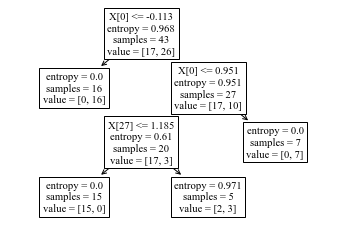

In [ ]:
tree.plot_tree(DT_classifier_improved)